# 계단 검출 — 후보 ① 하이브리드 베이스라인

> 프로젝트: **밤마실** / 파이프라인 ③ 위험 요소 탐지 — 계단

`docs/data.md` 4-1절 **후보 ① (고전 CV + 기하 검증)** 의 정량 baseline을 측정한다.

```
전처리(CLAHE) → Canny → HoughLinesP → 수평 선분 필터 → 병합 → 기하 검증
```

## 이 노트북이 답하려는 것

| 질문 | 왜 중요한가 |
|------|-------------|
| 야간 **재현율**이 얼마인가 | 계단은 낙상 위험의 안전 크리티컬 요소 — 놓치면 안 됨 |
| 야간 **정밀도**가 얼마인가 | 오탐이 많으면 화면이 지저분해져 잔존시력을 오히려 방해 |
| 주간 대비 야간 성능 저하폭 | 야간 특화 보강이 필요한지 판단 |
| **CLAHE 전처리의 효과** | `docs/data.md`의 "②단계를 먼저 통과시키면 엣지가 살아난다" 가정 검증 |

이 수치가 **(a) 하이브리드 강화 / (b) YOLO `stairs` 클래스 통합 / (c) StairNet 직접 학습** 선택의 판단 기준이 된다.

## 데이터

StairNet (Mendeley) — 512×512, 라벨은 **계단선 선분** `cls x1 y1 x2 y2` (cls: 0=convex, 1=concave)

| split | 전체 | 야간 |
|-------|------|------|
| val   | 424  | 76   |
| train | 2,670 | 429 |

> **한계**: 이 데이터셋에는 계단이 **없는** 이미지가 0장이다. 따라서 여기서 재는 정밀도는 *계단 장면 안에서의* 오탐만 반영하며, 계단이 없는 거리 장면에서의 오경보율은 측정되지 않는다. 해당 항목은 마지막 절에서 별도로 다룬다.

In [1]:
from __future__ import annotations

import math
from dataclasses import dataclass, replace
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 한글 라벨 깨짐 방지 (Windows)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

DATA = Path.cwd().parent / "data" / "Stair dataset"
assert DATA.is_dir(), f"데이터 경로 없음: {DATA}"


def load_split(split: str) -> pd.DataFrame:
    """이미지 경로 / 라벨 경로 / 야간 여부 목록."""
    rows = []
    for img in sorted((DATA / split / "images").glob("*.jpg")):
        lbl = DATA / split / "labels" / f"{img.stem}.txt"
        if lbl.exists():
            rows.append({"img": img, "lbl": lbl, "split": split,
                         "night": "night" in img.stem.lower()})
    return pd.DataFrame(rows)


def load_gt(lbl: Path) -> np.ndarray:
    """GT 선분 -> (N, 4) [x1, y1, x2, y2]. 클래스(convex/concave)는 사용하지 않는다.

    후보 ①은 '계단선이 있다/없다'만 판정하므로 상행·하행 구분은 평가 대상이 아니다.
    """
    out = []
    for line in lbl.read_text().strip().splitlines():
        p = line.split()
        if len(p) >= 5:
            out.append([float(p[1]), float(p[2]), float(p[3]), float(p[4])])
    return np.array(out, dtype=np.float32).reshape(-1, 4)


val, train = load_split("val"), load_split("train")
print(f"val   : {len(val):>5}장 (야간 {val.night.sum()})")
print(f"train : {len(train):>5}장 (야간 {train.night.sum()})")
print(f"야간 합계: {val.night.sum() + train.night.sum()}장")

val   :   424장 (야간 76)
train :  2670장 (야간 429)
야간 합계: 505장


## 1. 검출기

계단의 구조적 사전정보 — **평행한 수평 엣지의 반복** — 을 그대로 규칙으로 옮긴다. 학습·라벨링이 전혀 필요 없다.

| 단계 | 처리 | 목적 |
|------|------|------|
| 전처리 | 그레이스케일 → CLAHE → bilateral | 야간 암부의 **대비 복원**, 노이즈는 억제하되 엣지는 보존 |
| 엣지 | Canny | 계단 코 부분의 밝기 불연속 추출 |
| 선분 | HoughLinesP | 짧은 엣지 조각을 선분으로 |
| 필터 | 수평 ±`max_angle` | 수직 구조물(난간·기둥·건물) 제거 |
| 병합 | y·각도 근접 선분 통합 | 한 계단선이 여러 조각으로 쪼개지는 것 보정 |
| **기하 검증** | 개수 · 간격 규칙성 | **핵심** — 횡단보도·보도블록 줄눈 등 우연한 수평선 무리 배제 |

In [2]:
@dataclass(frozen=True)
class Cfg:
    # 전처리
    clahe: bool = True
    clahe_clip: float = 3.0
    # 엣지
    canny_lo: int = 40
    canny_hi: int = 120
    # Hough
    hough_thresh: int = 40
    min_len: int = 40
    max_gap: int = 12
    # 수평 필터 / 병합
    max_angle: float = 25.0   # 원근 때문에 계단선도 기울어진다 — 여유를 준다
    merge_y: float = 8.0
    merge_ang: float = 8.0
    # 기하 검증
    min_lines: int = 3        # 계단이라면 최소 3개 선이 반복되어야 함
    gap_ratio: float = 2.6    # 이웃 간격 비가 이 범위를 넘으면 규칙성 없음으로 판단


def preprocess(bgr: np.ndarray, cfg: Cfg) -> np.ndarray:
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    if cfg.clahe:
        gray = cv2.createCLAHE(clipLimit=cfg.clahe_clip,
                               tileGridSize=(8, 8)).apply(gray)
    return cv2.bilateralFilter(gray, 5, 50, 50)


def _angle(seg) -> float:
    x1, y1, x2, y2 = seg
    return math.degrees(math.atan2(y2 - y1, x2 - x1 + 1e-9))


def _merge(segs: list, cfg: Cfg) -> list:
    """y 중점과 각도가 가까운 선분을 하나로 통합.

    Hough는 한 계단선을 여러 조각으로 뱉는 경우가 많다. 병합하지 않으면
    선분 수가 부풀려져 정밀도가 실제보다 낮게 측정된다.
    """
    segs = sorted(segs, key=lambda s: (s[1] + s[3]) / 2)
    groups: list[list] = []
    for s in segs:
        ym, a = (s[1] + s[3]) / 2, _angle(s)
        for g in groups:
            gy = np.mean([(t[1] + t[3]) / 2 for t in g])
            ga = np.mean([_angle(t) for t in g])
            if abs(ym - gy) <= cfg.merge_y and abs(a - ga) <= cfg.merge_ang:
                g.append(s)
                break
        else:
            groups.append([s])

    merged = []
    for g in groups:  # 그룹의 x 범위 양끝을 잇는 대표 선분 생성
        pts = np.array([[s[0], s[1]] for s in g] + [[s[2], s[3]] for s in g])
        lo, hi = pts[pts[:, 0].argmin()], pts[pts[:, 0].argmax()]
        merged.append([float(lo[0]), float(lo[1]), float(hi[0]), float(hi[1])])
    return merged


def _verify(lines: list, cfg: Cfg) -> list:
    """기하 검증 — 계단의 '반복성'을 만족하는 최대 부분집합만 남긴다.

    라벨링이 전혀 필요 없는 단계이자, 후보 ①에서 오탐을 걷어내는 핵심.
    원근 때문에 간격은 위로 갈수록 좁아지므로 '등간격'이 아니라
    '이웃 간격 비가 완만하게 변하는가'를 본다.
    """
    if len(lines) < cfg.min_lines:
        return []
    lines = sorted(lines, key=lambda l: (l[1] + l[3]) / 2)
    ys = [(l[1] + l[3]) / 2 for l in lines]

    best: list[int] = []
    for i in range(len(ys)):          # 연속 구간 중 규칙성을 만족하는 최장 구간 탐색
        run = [i]
        for j in range(i + 1, len(ys)):
            cand = run + [j]
            if len(cand) >= 3:
                gaps = np.diff([ys[k] for k in cand])
                if gaps.min() <= 1e-6:
                    break
                ratios = gaps[1:] / gaps[:-1]
                if ratios.max() > cfg.gap_ratio or ratios.min() < 1 / cfg.gap_ratio:
                    break
            run = cand
        if len(run) > len(best):
            best = run
    return [lines[k] for k in best] if len(best) >= cfg.min_lines else []


def detect(bgr: np.ndarray, cfg: Cfg = Cfg()) -> dict:
    """계단선 검출. 중간 산출물도 함께 돌려줘 시각화·디버깅에 쓴다."""
    gray = preprocess(bgr, cfg)
    edges = cv2.Canny(gray, cfg.canny_lo, cfg.canny_hi, apertureSize=3)
    raw = cv2.HoughLinesP(edges, 1, np.pi / 180, cfg.hough_thresh,
                          minLineLength=cfg.min_len, maxLineGap=cfg.max_gap)
    # OpenCV 5.x는 (N,4), 4.x는 (N,1,4)를 반환한다 — 양쪽 모두 흡수
    raw = [] if raw is None else np.asarray(raw).reshape(-1, 4).tolist()
    horiz = [s for s in raw if abs(_angle(s)) <= cfg.max_angle]
    merged = _merge(horiz, cfg)
    return {"gray": gray, "edges": edges, "raw": raw,
            "horiz": horiz, "merged": merged, "lines": _verify(merged, cfg)}

## 2. 단계별 시각화

야간 샘플에서 각 단계가 무엇을 걸러내는지 눈으로 확인한다.

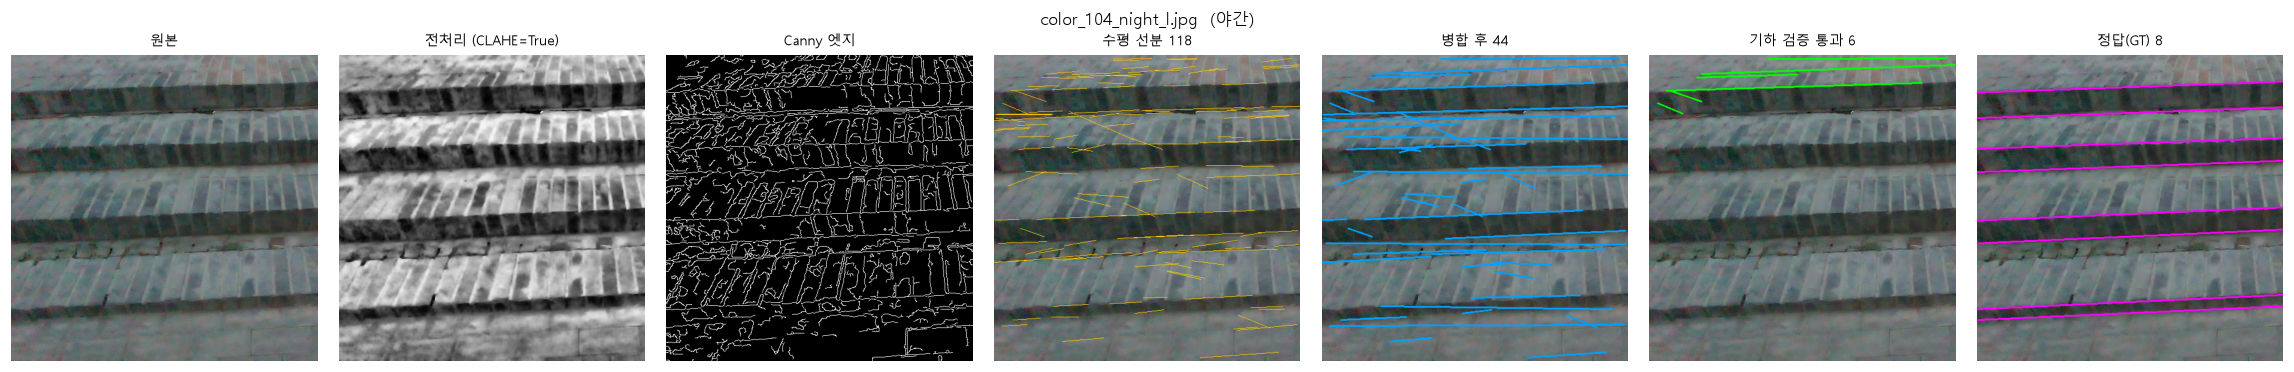

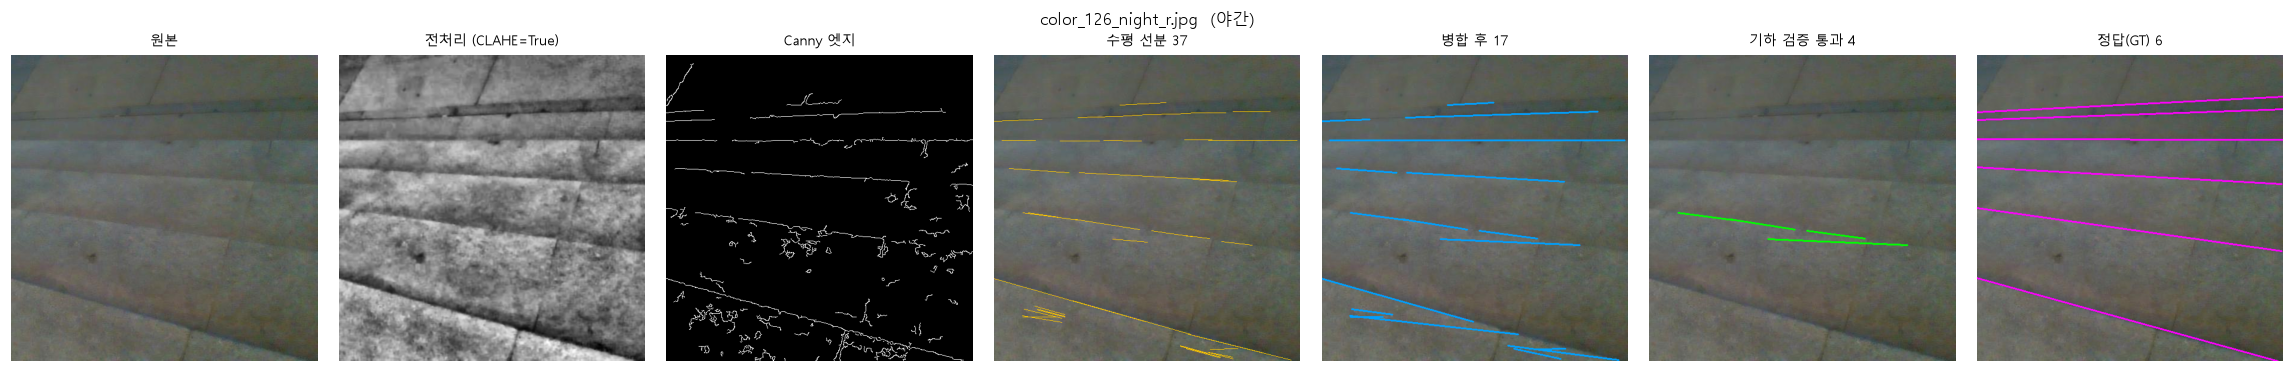

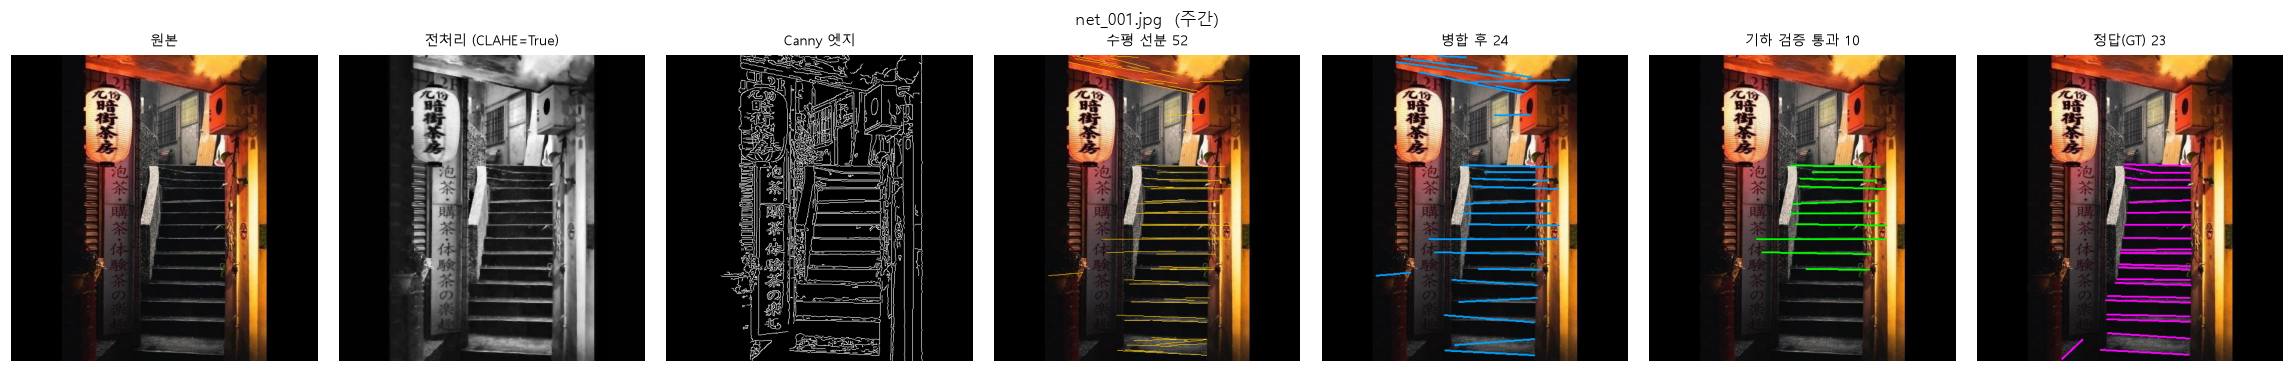

In [3]:
def draw(bgr, lines, color=(0, 255, 0), thick=2):
    out = bgr.copy()
    for x1, y1, x2, y2 in lines:
        cv2.line(out, (int(x1), int(y1)), (int(x2), int(y2)), color, thick)
    return cv2.cvtColor(out, cv2.COLOR_BGR2RGB)


def show_stages(row, cfg=Cfg()):
    bgr = cv2.imread(str(row.img))
    r = detect(bgr, cfg)
    gt = load_gt(row.lbl)
    panels = [
        (cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB), "원본"),
        (r["gray"], f"전처리 (CLAHE={cfg.clahe})"),
        (r["edges"], "Canny 엣지"),
        (draw(bgr, r["horiz"], (0, 200, 255), 1), f"수평 선분 {len(r['horiz'])}"),
        (draw(bgr, r["merged"], (255, 160, 0)), f"병합 후 {len(r['merged'])}"),
        (draw(bgr, r["lines"]), f"기하 검증 통과 {len(r['lines'])}"),
        (draw(bgr, gt, (255, 0, 255)), f"정답(GT) {len(gt)}"),
    ]
    fig, axes = plt.subplots(1, len(panels), figsize=(3 * len(panels), 3.4))
    for ax, (im, t) in zip(axes, panels):
        ax.imshow(im, cmap="gray" if im.ndim == 2 else None)
        ax.set_title(t, fontsize=9)
        ax.axis("off")
    fig.suptitle(f"{row.img.name}  ({'야간' if row.night else '주간'})", fontsize=11)
    plt.tight_layout()
    plt.show()


night_rows = val[val.night].reset_index(drop=True)
day_rows = val[~val.night].reset_index(drop=True)
for i in (0, 5):
    show_stages(night_rows.iloc[i])
show_stages(day_rows.iloc[0])

## 3. 평가 방법

선분 단위 매칭으로 precision / recall / F1을 계산한다.

**검출선이 GT선과 매칭되는 조건** (모두 만족):
1. x 구간이 겹칠 것 (겹침 폭 ≥ `min_overlap`px)
2. 겹치는 구간 중앙에서의 **y 차이 ≤ `tol_y`px**
3. 각도 차이 ≤ `tol_ang`°

GT 하나에 검출 하나만 대응하도록 **y 오차가 작은 순서로 탐욕 매칭**한다. `tol_y = 10px`은 512px 높이의 약 2%로, 계단 한 단 높이(이미지상 20~50px)보다 충분히 작아 인접 계단선끼리 섞이지 않는다.

In [4]:
def _y_at(line, x):
    x1, y1, x2, y2 = line
    return y1 if abs(x2 - x1) < 1e-6 else y1 + (y2 - y1) * (x - x1) / (x2 - x1)


def match_lines(det, gt, tol_y=10.0, tol_ang=15.0, min_overlap=30.0):
    """(TP, FP, FN) 계산."""
    pairs = []
    for di, d in enumerate(det):
        for gi, g in enumerate(gt):
            lo = max(min(d[0], d[2]), min(g[0], g[2]))
            hi = min(max(d[0], d[2]), max(g[0], g[2]))
            if hi - lo < min_overlap:
                continue
            if abs(_angle(d) - _angle(g)) > tol_ang:
                continue
            mid = (lo + hi) / 2
            dy = abs(_y_at(d, mid) - _y_at(g, mid))
            if dy <= tol_y:
                pairs.append((dy, di, gi))

    used_d, used_g = set(), set()
    for dy, di, gi in sorted(pairs):          # 오차 작은 쌍부터 확정
        if di not in used_d and gi not in used_g:
            used_d.add(di)
            used_g.add(gi)
    tp = len(used_d)
    return tp, len(det) - tp, len(gt) - tp


def evaluate(df: pd.DataFrame, cfg: Cfg = Cfg()) -> dict:
    TP = FP = FN = 0
    empty = 0                                  # 계단을 하나도 못 찾은 이미지
    for row in df.itertuples():
        bgr = cv2.imread(str(row.img))
        det = detect(bgr, cfg)["lines"]
        empty += not det
        tp, fp, fn = match_lines(det, load_gt(row.lbl))
        TP, FP, FN = TP + tp, FP + fp, FN + fn
    p = TP / (TP + FP) if TP + FP else 0.0
    r = TP / (TP + FN) if TP + FN else 0.0
    return {"n": len(df), "TP": TP, "FP": FP, "FN": FN,
            "precision": p, "recall": r,
            "f1": 2 * p * r / (p + r) if p + r else 0.0,
            "미검출 이미지": empty,
            "미검출률": empty / len(df) if len(df) else 0.0}


print("평가 함수 준비 완료")

평가 함수 준비 완료


## 4. 정량 평가

야간 505장(val 76 + train 429) 전량과 주간 대조군에 대해 측정한다.

동시에 **CLAHE on/off** 를 비교해 `docs/data.md`의 "② 저조도 개선을 먼저 통과시키면 엣지가 살아나 고전 CV 성능이 크게 개선된다" 가정을 검증한다. (② 딥러닝 모델이 아직 없으므로 고전 톤매핑인 CLAHE를 대역으로 사용 — 실제 ②단계를 붙이면 이보다 개선될 여지가 있다.)

In [5]:
subsets = {
    "야간 (val)": val[val.night],
    "야간 (train)": train[train.night],
    "주간 (val)": val[~val.night],
    "주간 (train, 400장 샘플)": train[~train.night].sample(400, random_state=0),
}

records = []
for use_clahe in (True, False):
    cfg = replace(Cfg(), clahe=use_clahe)
    for name, df in subsets.items():
        m = evaluate(df, cfg)
        records.append({"전처리": "CLAHE" if use_clahe else "raw",
                        "대상": name, **m})
        print(f"[{'CLAHE' if use_clahe else 'raw  '}] {name:<22} "
              f"P={m['precision']:.3f} R={m['recall']:.3f} F1={m['f1']:.3f} "
              f"미검출={m['미검출률']:.1%}")

res = pd.DataFrame(records)

[CLAHE] 야간 (val)               P=0.289 R=0.261 F1=0.274 미검출=1.3%


[CLAHE] 야간 (train)             P=0.238 R=0.227 F1=0.232 미검출=1.4%


[CLAHE] 주간 (val)               P=0.353 R=0.271 F1=0.306 미검출=0.6%


[CLAHE] 주간 (train, 400장 샘플)    P=0.280 R=0.222 F1=0.248 미검출=0.0%


[raw  ] 야간 (val)               P=0.370 R=0.236 F1=0.288 미검출=23.7%


[raw  ] 야간 (train)             P=0.378 R=0.212 F1=0.272 미검출=28.4%


[raw  ] 주간 (val)               P=0.523 R=0.360 F1=0.427 미검출=3.7%


[raw  ] 주간 (train, 400장 샘플)    P=0.448 R=0.312 F1=0.368 미검출=7.0%


In [6]:
cols = ["전처리", "대상", "n", "precision", "recall", "f1", "미검출률"]
display(res[cols].style.format({"precision": "{:.3f}", "recall": "{:.3f}",
                                "f1": "{:.3f}", "미검출률": "{:.1%}"})
        .background_gradient(subset=["recall", "f1"], cmap="RdYlGn", vmin=0, vmax=1))

,전처리,대상,n,precision,recall,f1,미검출률
0,CLAHE,야간 (val),76,0.289,0.261,0.274,1.3%
1,CLAHE,야간 (train),429,0.238,0.227,0.232,1.4%
2,CLAHE,주간 (val),348,0.353,0.271,0.306,0.6%
3,CLAHE,"주간 (train, 400장 샘플)",400,0.280,0.222,0.248,0.0%
4,raw,야간 (val),76,0.370,0.236,0.288,23.7%
5,raw,야간 (train),429,0.378,0.212,0.272,28.4%
6,raw,주간 (val),348,0.523,0.360,0.427,3.7%
7,raw,"주간 (train, 400장 샘플)",400,0.448,0.312,0.368,7.0%


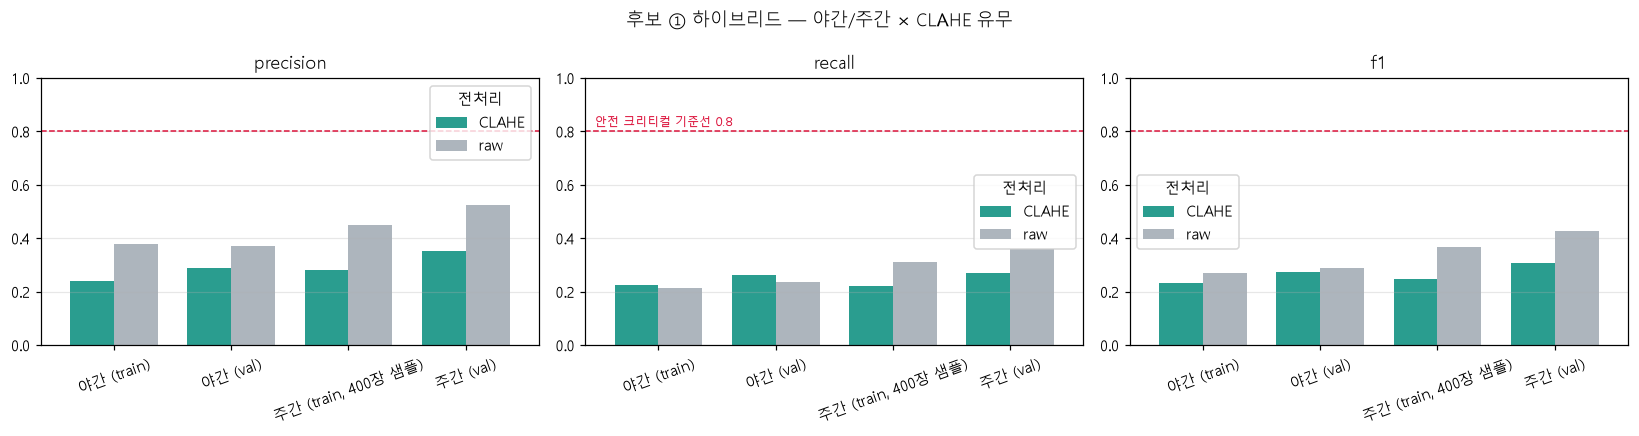

야간 F1에 대한 CLAHE 효과: -0.027


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric in zip(axes, ["precision", "recall", "f1"]):
    piv = res.pivot(index="대상", columns="전처리", values=metric)
    piv.plot.bar(ax=ax, rot=20, width=0.75,
                 color={"CLAHE": "#2a9d8f", "raw": "#adb5bd"})
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    ax.set_xlabel("")
    ax.grid(axis="y", alpha=0.3)
    ax.axhline(0.8, ls="--", c="crimson", lw=1)

axes[1].text(0.02, 0.82, "안전 크리티컬 기준선 0.8", color="crimson", fontsize=8,
             transform=axes[1].get_yaxis_transform())
plt.suptitle("후보 ① 하이브리드 — 야간/주간 × CLAHE 유무", fontsize=12)
plt.tight_layout()
plt.show()

night = res[res["대상"].str.startswith("야간")]
delta = (night[night.전처리 == "CLAHE"].f1.mean()
         - night[night.전처리 == "raw"].f1.mean())
print(f"야간 F1에 대한 CLAHE 효과: {delta:+.3f}")

## 5. 실패 사례 분석

재현율이 낮은 이미지를 직접 보고 원인을 분류한다 — 개선 방향이 여기서 나온다.

야간 505장 — 이미지별 재현율 중앙값 0.182
재현율 0인 이미지: 145장 (28.7%)


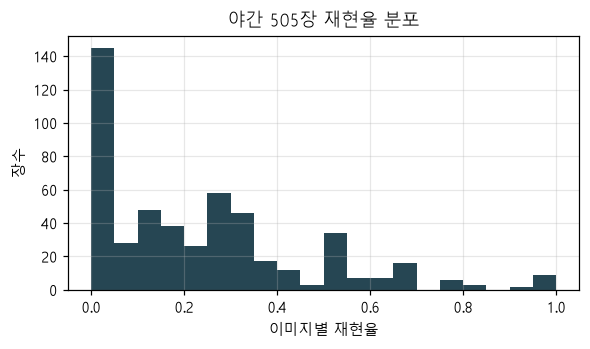

In [8]:
cfg = Cfg()
per_img = []
for row in pd.concat([val[val.night], train[train.night]]).itertuples():
    det = detect(cv2.imread(str(row.img)), cfg)["lines"]
    gt = load_gt(row.lbl)
    tp, fp, fn = match_lines(det, gt)
    per_img.append({"img": row.img, "lbl": row.lbl, "night": True,
                    "recall": tp / len(gt) if len(gt) else np.nan,
                    "n_det": len(det), "n_gt": len(gt)})
per_img = pd.DataFrame(per_img)

print(f"야간 {len(per_img)}장 — 이미지별 재현율 중앙값 {per_img.recall.median():.3f}")
print(f"재현율 0인 이미지: {(per_img.recall == 0).sum()}장 "
      f"({(per_img.recall == 0).mean():.1%})")

plt.figure(figsize=(6, 3))
plt.hist(per_img.recall.dropna(), bins=20, color="#264653")
plt.xlabel("이미지별 재현율")
plt.ylabel("장수")
plt.title("야간 505장 재현율 분포")
plt.grid(alpha=0.3)
plt.show()

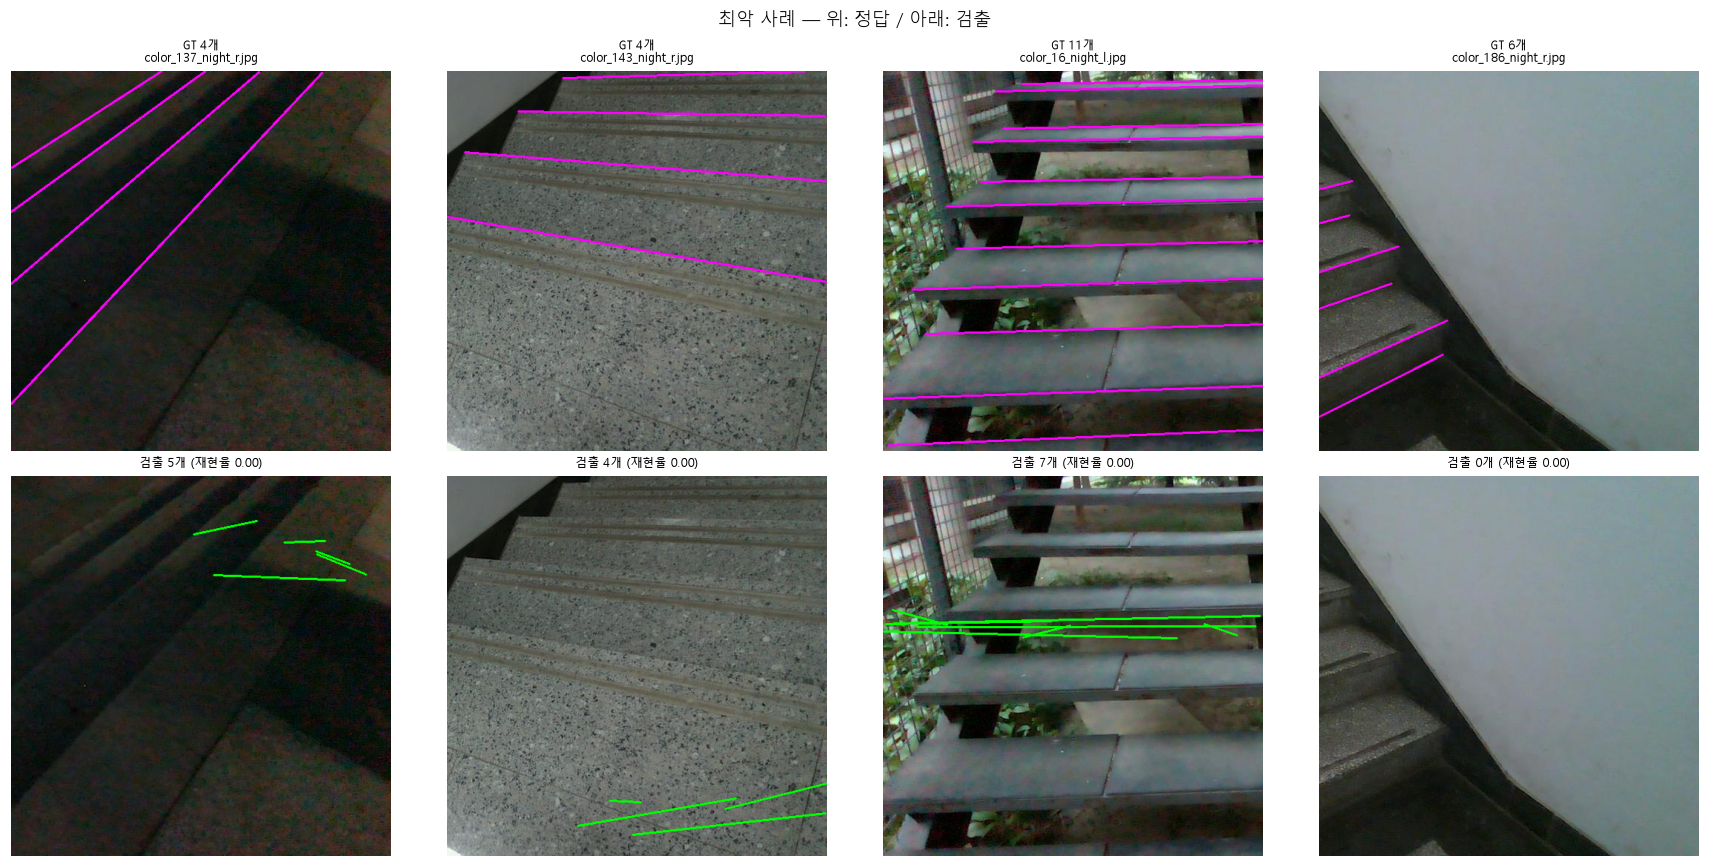

In [9]:
worst = per_img.nsmallest(4, "recall")
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for k, row in enumerate(worst.itertuples()):
    bgr = cv2.imread(str(row.img))
    r = detect(bgr, cfg)
    axes[0, k].imshow(draw(bgr, load_gt(row.lbl), (255, 0, 255)))
    axes[0, k].set_title(f"GT {row.n_gt}개\n{row.img.name}", fontsize=8)
    axes[1, k].imshow(draw(bgr, r["lines"]))
    axes[1, k].set_title(f"검출 {row.n_det}개 (재현율 {row.recall:.2f})", fontsize=8)
    for ax in (axes[0, k], axes[1, k]):
        ax.axis("off")
plt.suptitle("최악 사례 — 위: 정답 / 아래: 검출", fontsize=12)
plt.tight_layout()
plt.show()

## 6. 오경보(false alarm) — 계단이 없는 장면

StairNet에는 계단 없는 이미지가 0장이라 위 정밀도로는 **"계단이 아닌 것을 계단이라 하는"** 오탐을 잴 수 없다.

보행 중 실제로 마주치는 야간 거리 장면(LoLI-Street RLLT)에 검출기를 돌려 **계단이라고 주장하는 비율**을 본다. RLLT에도 계단이 일부 포함될 수 있으므로 이 값은 오경보율의 **상한**으로 읽어야 한다.

야간 거리 장면 300장 중 계단 검출 발생: 300장 (100.0%) — 오경보율 상한


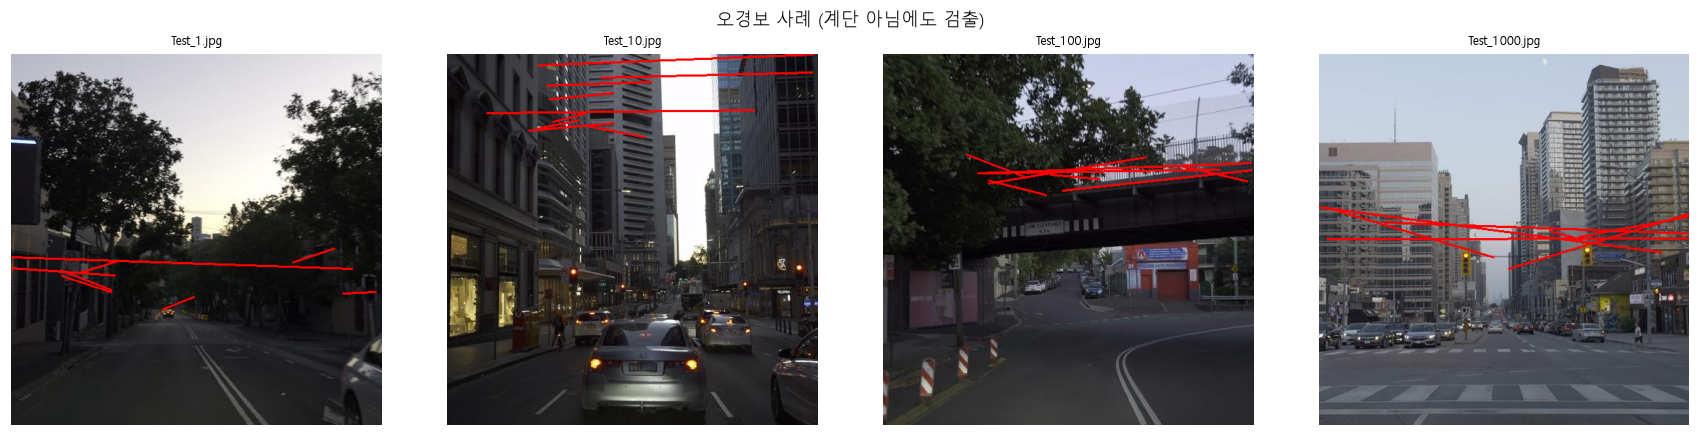

In [10]:
rllt = sorted((Path.cwd().parent / "data" / "LoLI-Street" /
               "LoLI-Street Dataset" / "Test").glob("*.jpg"))[:300]

fired = [p for p in rllt if detect(cv2.imread(str(p)), cfg)["lines"]]
print(f"야간 거리 장면 {len(rllt)}장 중 계단 검출 발생: "
      f"{len(fired)}장 ({len(fired) / len(rllt):.1%}) — 오경보율 상한")

if fired:
    fig, axes = plt.subplots(1, min(4, len(fired)), figsize=(16, 4))
    for ax, p in zip(np.atleast_1d(axes), fired[:4]):
        bgr = cv2.imread(str(p))
        ax.imshow(draw(bgr, detect(bgr, cfg)["lines"], (0, 0, 255)))
        ax.set_title(p.name, fontsize=8)
        ax.axis("off")
    plt.suptitle("오경보 사례 (계단 아님에도 검출)", fontsize=12)
    plt.tight_layout()
    plt.show()

## 7. 결론 — (a)/(b)/(c) 판단

아래 셀이 측정 결과를 판단 기준에 대입한다.

| 조건 | 해석 | 다음 수순 |
|------|------|-----------|
| 야간 재현율 ≥ 0.8 & 오경보 낮음 | 후보 ① 단독으로 충분 | 파이프라인에 그대로 탑재, 딥러닝 보강 불필요 |
| 재현율 양호 · **정밀도/오경보 문제** | 검증 단계가 약함 | **(a)** 소형 이진 분류기로 검증 강화 (라벨링 부담 최소) |
| **재현율 부족** | 구조적 사전정보만으로 한계 | **(b)** YOLO `stairs` 클래스 통합 — 자체 야간 BBox 라벨링 착수 |
| 재현율·정밀도 모두 크게 부족 | 영역 단위로도 부족 | **(c)** StairNet 계열 직접 학습 (비용 최대, 최후) |

> 계단은 **낙상 위험의 안전 크리티컬 요소**이므로 재현율을 정밀도보다 우선한다.

In [11]:
night_clahe = res[(res.전처리 == "CLAHE") & res["대상"].str.startswith("야간")]
day_clahe = res[(res.전처리 == "CLAHE") & res["대상"].str.startswith("주간")]

R = float(np.average(night_clahe.recall, weights=night_clahe.n))
P = float(np.average(night_clahe.precision, weights=night_clahe.n))
R_day = float(np.average(day_clahe.recall, weights=day_clahe.n))
FA = len(fired) / len(rllt)

print(f"야간 재현율      : {R:.3f}")
print(f"야간 정밀도      : {P:.3f}")
print(f"주간 재현율      : {R_day:.3f}   (야간 저하폭 {R_day - R:+.3f})")
print(f"오경보율 상한    : {FA:.1%}")
print(f"CLAHE 효과(F1)   : {delta:+.3f}")
print("-" * 46)

if R >= 0.8 and FA < 0.15:
    verdict = "후보 ① 단독 채택 가능 — 딥러닝 보강 불필요"
elif R >= 0.8:
    verdict = "(a) 소형 이진 분류기로 검증 강화 — 재현율은 충분, 오탐이 문제"
elif R >= 0.5:
    verdict = "(b) YOLO `stairs` 클래스 통합 권장 — 재현율 부족"
else:
    verdict = "(b) 우선 시도, 미달 시 (c) — 재현율이 안전 기준에 크게 미달"
print("판단:", verdict)

야간 재현율      : 0.232
야간 정밀도      : 0.246
주간 재현율      : 0.245   (야간 저하폭 +0.013)
오경보율 상한    : 100.0%
CLAHE 효과(F1)   : -0.027
----------------------------------------------
판단: (b) 우선 시도, 미달 시 (c) — 재현율이 안전 기준에 크게 미달
